In [1]:
import jax
from jax import config
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    config.update("jax_platform_name", "gpu")
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/jaxley_rgc
    !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"
else: 
    config.update("jax_platform_name", "cpu")

In [2]:
from jax.nn import softplus
import jax.numpy as jnp
import numpy as np
from utils.training_utils import K_func, ln_forward, make_rgc_forward_with_states, softplus_beta
from utils.utils import upsample_hold_edges
from utils.v_to_rate import voltage_batch_to_mu, make_edges, voltage_to_rate_sigmoid_clipped
from utils.rgc import build_cell, simulate_one_trial, rgc_forward_sim
from utils.spk_detection import voltage_batch_to_spikes, idx_to_times, poisson_counts_from_rate

import matplotlib.pyplot as plt
import jaxley as jx
plt.rcParams["figure.dpi"] = 100
plt.rcParams['axes.labelsize'] = 18

import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)


# Stim

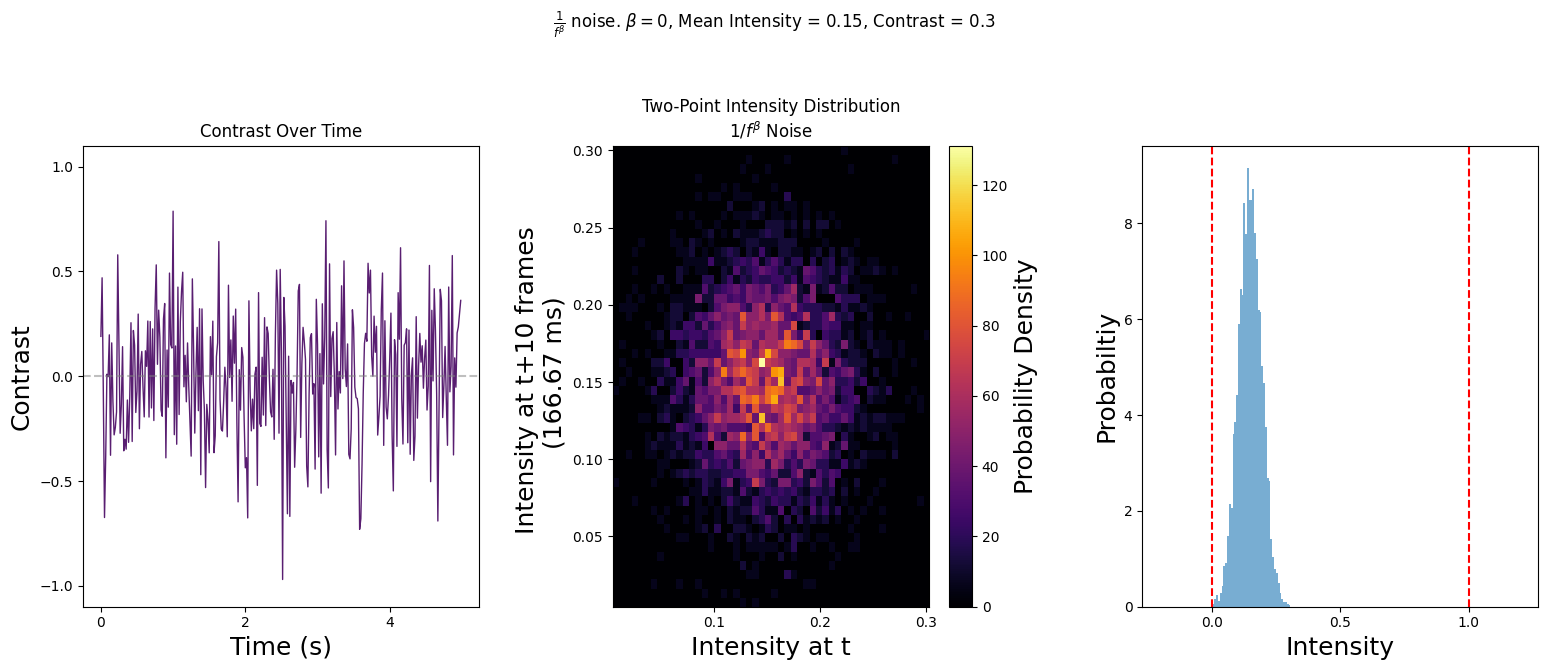

In [3]:
from utils.stim_utils import generate_1_f_noise, plot_stim
beta= 0
mean_intensity = 0.15
desired_contrast = 0.3
stim_duration = 5
trials = 15
frame_rate = 60
dt_stim = 1/frame_rate
frame_dwell = 1
tau = 10

all_noise = []
all_contrast = []
for trial in range(trials):
    noise, contrast = generate_1_f_noise(
        beta, frame_rate * stim_duration, frame_rate,
        frame_dwell, mean_intensity, desired_contrast,
        noise_seed=trial)
    all_noise.append(noise)
    all_contrast.append(contrast)

noise_t = jnp.concatenate(all_noise)
contrast_t = jnp.concatenate(all_contrast)
stim = jnp.array(all_contrast)

plot_stim(noise_t=noise_t, contrast_mat=stim,
          beta=beta,
          mean_intensity=mean_intensity,
          desired_contrast=desired_contrast,
          tau=10, frame_rate=60, figsize=(16,7))

## Build Simulated data

In [4]:
### COMMON PARAM BUILDER FUNCTIONS  
def softplus_inv(y, eps=1e-8):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))
  
def ln_params(key,
              alpha_j0,
              alpha_h0,
              logit_tau10,
              logit_tau20,
              beta0,
              gain0,
              r0,
              shift0,
              noise):
    eps = noise * jax.random.normal(key, (7,), dtype=jnp.float32)
    return {
      "logit_tau1": jnp.array(logit_tau10, jnp.float32) + eps[0],
      "logit_tau2": jnp.array(logit_tau20, jnp.float32) + eps[1],
      "alpha_j":    jnp.array(alpha_j0,   jnp.float32)  * (1.0 + 0.1*eps[2]),
      "alpha_h":    jnp.array(alpha_h0,   jnp.float32)  * (1.0 + 0.1*eps[3]),
      "log_beta": softplus_inv(beta0) + eps[4],
      "log_gain": softplus_inv(gain0) + eps[5],  # Start with gain ~ 1.0
    "log_r0":     jnp.log(jnp.array(r0,   dtype=jnp.float32)),
      "shift":      jnp.array(shift0, jnp.float32) + 0.05*eps[6],
    }

In [5]:
## BUILC CELL
dt_cell_ms = 0.05
dt_cell_s = dt_cell_ms * 1e-3

# R_Mohm = 228.7
# dV     = 5.0
key = jax.random.PRNGKey(0)
ground_params = ln_params(key,
                        alpha_j0=0.16,
                        alpha_h0=0.38,
                        logit_tau10=0.55,
                        logit_tau20=-0.57,
                        beta0=2.285,
                        gain0 = 3,
                        r0 = 0.12,
                        shift0=0.46,
                        noise=0.05)


filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive_ground, L, K_ground  =  ln_forward(ground_params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


0.0034021593
0.008670266 0.44192794


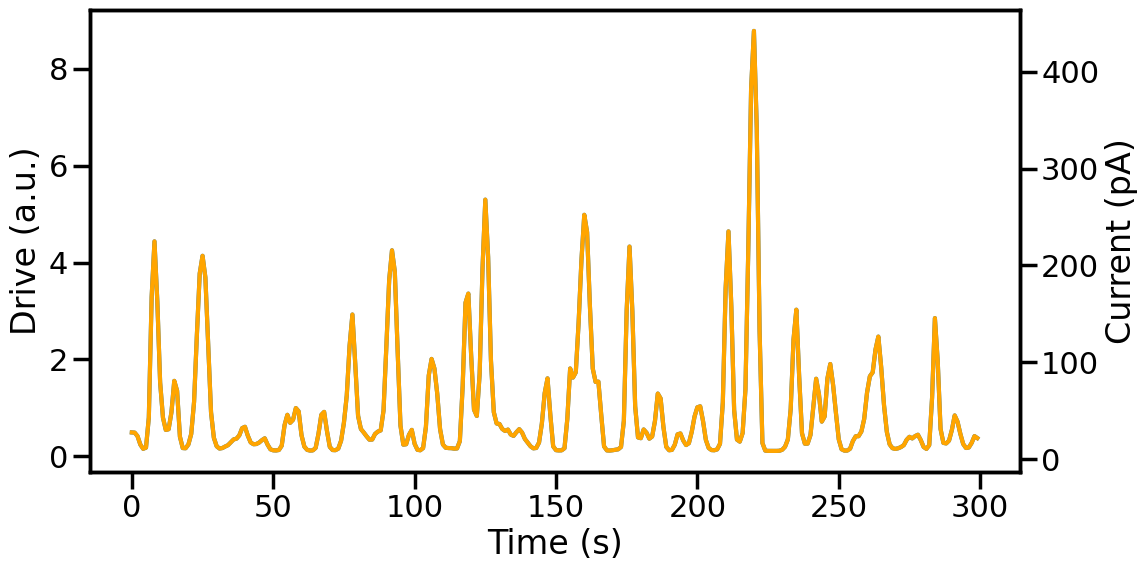

In [6]:
## Affine map of drive to current, with parameters chosen to keep current >= 0 for all drive values in the data
def current_map(drive, a=0.05, b=0.003):
    # choose b > a*|min(drive)| so output stays >= 0
    return jnp.maximum(1e-4, b + a * drive)
I_f_ground = current_map(drive_ground)
fig, axes = plt.subplots(1,1, figsize=(12,6), sharex=True)
axes.plot(drive_ground[0])
axes.set_xlabel("Time (s)")
axes.set_ylabel("Drive (a.u.)")
_ = axes.twinx()
_.plot(I_f_ground[0]*1000, color='orange')
_.set_ylabel("Current (pA)")

print(0.03 * jnp.abs(drive_ground).min())
print(I_f_ground.min(), I_f_ground.max())

In [7]:
# Build cell
cell_ground = build_cell()
cell_ground.delete_recordings()
cell_ground.record("v")

# build once per cell
rgc_forwardg = make_rgc_forward_with_states(cell_ground, dt_cell_ms)
rgc_forwardg = jax.jit(rgc_forwardg)

Added 1 recordings. See `.recordings` for details.


In [8]:

def forward_pass(drive, r_max_hz, beta, rgc_forward, edges_hat):
    I_f = current_map(drive)
    T_f = I_f.shape[-1]
    T_cell = int(round(T_f * dt_stim / dt_cell_s))  # static if T_f fixed
    I_syn = upsample_hold_edges(I_f, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

    v_batch = rgc_forward(I_syn)
    rate, mu_batch = voltage_batch_to_mu(
        v_batch, edges_hat, sr_v=1.0/dt_cell_s, vth=-45, beta=beta, r_max_hz=r_max_hz, vcap=-20
    )
    return v_batch, mu_batch, I_syn


r_max_hz = 1000/4
beta = 0.5

T_vg = rgc_forwardg(upsample_hold_edges(current_map(drive_ground), dt_stim=dt_stim, dt_cell=dt_cell_s,
                                        T_cell=int(round(drive_ground.shape[-1]*dt_stim/dt_cell_s)))).shape[1]
edges_hatg = make_edges(T_vg, sr_v=1.0/dt_cell_s, fr=60.0)

V_ground, mu_ground, I_syn_ground =  forward_pass(drive_ground, r_max_hz, beta, rgc_forwardg, edges_hatg)

In [9]:
spk_bool, spk_idx_padded, n_spk, spk_train = voltage_batch_to_spikes(
    V_ground,
    dt_v=dt_cell_s,
    edges=edges_hatg,
    vth=0.0,        # try 0mV first; if too strict/lenient change to e.g. -10 or +10
    refrac_ms=2.0
)

# key = jax.random.PRNGKey(0)
# y_counts, mu = poisson_counts_from_rate(drive_ground, dt=1/60, key=key)
spk_times_padded = idx_to_times(spk_idx_padded, dt_cell_s)

print("spk_bool:", spk_bool.shape)                 # (50, T_v)
print("spk_train_60:", spk_train.shape)         # (50, T_f)
print("n_spk (first 10):", n_spk[:10])
# print("y_counts:", y_counts.shape)                 # (T_f,)


spk_bool: (15, 100000)
spk_train_60: (15, 300)
n_spk (first 10): [34 24 26 31 37 39 33 29 31 43]


In [10]:
import jax.numpy as jnp

# spk_times_padded: (N, Smax), padded with -dt_v for invalid entries (from idx_to_times)
# n_spk: (N,) number of valid spikes per trial

def min_isi_per_trial(spk_times_padded, n_spk):
    N, Smax = spk_times_padded.shape
    trial_ids = jnp.arange(N)

    def one_trial(i):
        k = n_spk[i]
        t = spk_times_padded[i, :k]           # valid spike times only
        isi = jnp.diff(t)                     # length k-1
        # if fewer than 2 spikes, return +inf
        return jnp.where(k >= 2, jnp.min(isi), jnp.inf)

    return jnp.array([one_trial(i) for i in trial_ids])

min_isi_trials = min_isi_per_trial(spk_times_padded, n_spk)
global_min_isi = jnp.min(min_isi_trials)

print("min ISI per trial (ms):", min_isi_trials*1000)
print("global shortest ISI (ms):", float(global_min_isi*1e3))
print("global shortest ISI (ms):", float(global_min_isi * 1e3))


min ISI per trial (ms): [3.899932  3.8499832 3.8000345 3.8499832 3.8499832 3.8499832 3.950119
 3.799975  3.8499832 3.8000345 3.8499832 3.8499832 3.8499832 3.8000345
 3.8499832]
global shortest ISI (ms): 3.7999749183654785
global shortest ISI (ms): 3.7999749183654785


In [11]:
## Optimize voltage to rate conversion for data!!
# import jax
# import jax.numpy as jnp
# import optax
# from jax.nn import softplus
# from functools import partial
# from utils.v_to_rate import rate_to_mu_with_edges

# def softplus_inv_stable(y):
#     y = jnp.asarray(y, dtype=jnp.float32)
#     return jnp.where(y > 20.0, y + jnp.log1p(-jnp.exp(-y)), jnp.log(jnp.expm1(y)))

# def beta_from_params(p):
#     return jnp.clip(softplus(p["log_beta"]) + 1e-6, 1e-4, 20.0)

# def voltage_to_rate_sigmoid_safe(V, r_max_hz, vth, beta, vcap=-20.0):
#     Vc = jnp.minimum(V, vcap)
#     x = jnp.clip(beta * (Vc - vth), -40.0, 40.0)
#     p = 1.0 / (1.0 + jnp.exp(-x))
#     return r_max_hz * p + 1e-8

# @partial(jax.jit, static_argnames=("sr_v",))
# def predict_mu_beta_only(params, V_batch, edges, *, sr_v, r_max_hz_fixed, vth=-20.0, vcap=-20.0):
#     beta = beta_from_params(params)
#     rate_batch = jax.vmap(
#         lambda V: voltage_to_rate_sigmoid_safe(V, r_max_hz_fixed, vth, beta, vcap),
#         in_axes=0
#     )(V_batch)
#     mu_batch = jax.vmap(lambda r: rate_to_mu_with_edges(r, edges, sr_v=sr_v), in_axes=0)(rate_batch)
#     return mu_batch, rate_batch

# @jax.jit
# def poisson_nll_mu(mu, y, eps=1e-8):
#     mu = jnp.clip(mu, eps, 1e9)
#     y = y.astype(mu.dtype)
#     return jnp.mean(mu - y * jnp.log(mu))

# @partial(jax.jit, static_argnames=("sr_v",))
# def loss_fn(params, V_batch, y_counts, edges, *, sr_v, r_max_hz_fixed, vth=-20.0, vcap=-20.0, w=1e-6):
#     mu, _ = predict_mu_beta_only(
#         params, V_batch, edges, sr_v=sr_v,
#         r_max_hz_fixed=r_max_hz_fixed, vth=vth, vcap=vcap
#     )
#     data = poisson_nll_mu(mu, y_counts)
#     reg = w * jnp.sum(params["log_beta"]**2)
#     return data + reg

# @partial(jax.jit, static_argnames=("sr_v",))
# def train_step(params, opt_state, V_batch, y_counts, edges, *, sr_v, r_max_hz_fixed, vth=-20.0, vcap=-20.0, w=1e-6):
#     loss, grads = jax.value_and_grad(loss_fn)(
#         params, V_batch, y_counts, edges,
#         sr_v=sr_v, r_max_hz_fixed=r_max_hz_fixed, vth=vth, vcap=vcap, w=w
#     )
#     updates, opt_state = optimizer.update(grads, opt_state, params)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss

# # ---- setup ----
# # Example:
# # min_isi_s = float(global_min_isi)  # from your previous cell
# # r_max_hz_fixed = 1.0 / min_isi_s
# r_max_hz_fixed = 260.0  # if refrac_ms=2.0 exactly

# params = {"log_beta": softplus_inv_stable(0.5)}
# optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-2))
# opt_state = optimizer.init(params)

# y_target = spk_train.astype(jnp.float32)  # or y_counts oracle

# for it in range(600):
#     params, opt_state, loss = train_step(
#         params, opt_state, V_ground, y_target, edges_hat,
#         sr_v=sr_v, r_max_hz_fixed=r_max_hz_fixed, vth=-20.0, vcap=-20.0, w=1e-6
#     )
#     if it % 100 == 0:
#         print(it, float(loss), float(beta_from_params(params)))

# beta_fit = float(beta_from_params(params))
# print("beta_fit:", beta_fit, "r_max_fixed:", r_max_hz_fixed)

# mu_hat_fit, rate_hat_fit = predict_mu_beta_only(
#     params, V_ground, edges_hat, sr_v=sr_v,
#     r_max_hz_fixed=r_max_hz_fixed, vth=-20.0, vcap=-20.0
# )


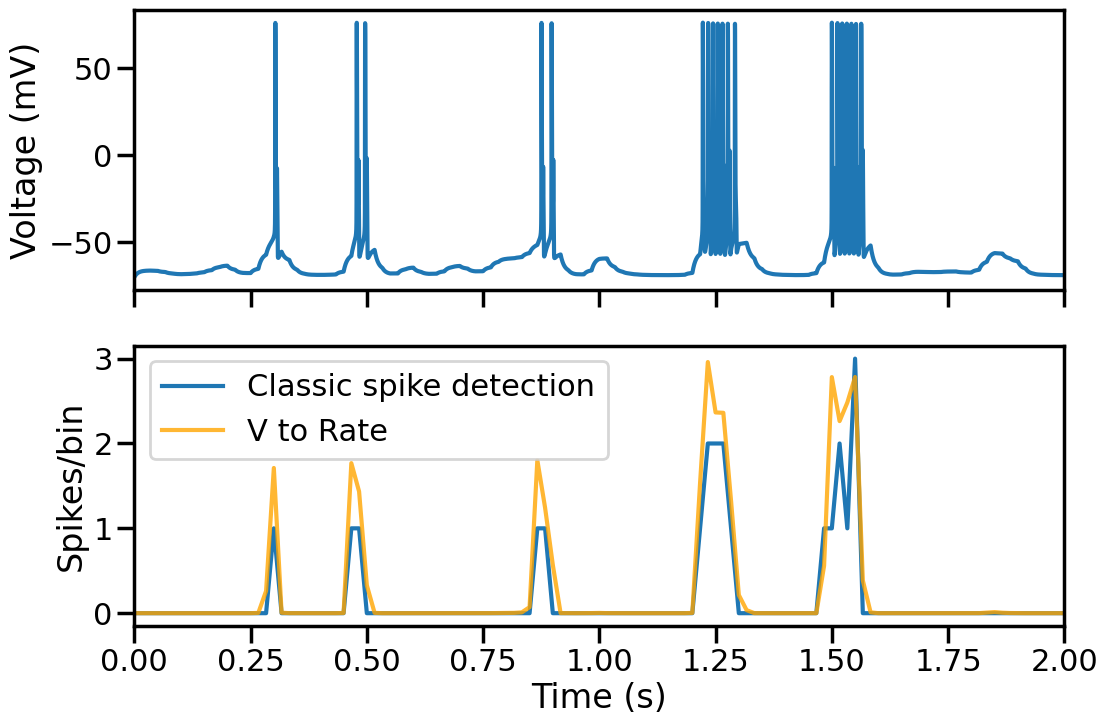

In [13]:
trial = 2
fig, axes = plt.subplots(2,1, figsize=(12,8), sharex=True)
t_v = jnp.arange(T_vg) * dt_cell_s
t_spk = jnp.arange(spk_train.shape[1]) * dt_stim
axes[0].plot(t_v, V_ground[trial].T)
axes[0].set_ylabel("Voltage (mV)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Spikes/bin")    
axes[1].plot(t_spk, spk_train[trial], label='Classic spike detection')
axes[1].plot(t_spk, mu_ground[trial], label='V to Rate', color='orange', alpha=0.8)
axes[1].legend()
for ax in axes:
    ax.set_xlim(0,2)

## Build initial params cell

In [14]:
params_ln0 = ln_params(key,
                    alpha_j0=0.5,
                    alpha_h0=0.2,
                    logit_tau10=0.65,
                    logit_tau20=-0.57,
                    beta0=2.285,
                    gain0 = 2,
                    r0 = 0.12,
                    shift0=-0.46,
                    noise=0.2)

filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive0, L, K0 =  ln_forward(params_ln0, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")

rgc_forward0 = make_rgc_forward_with_states(cell0, dt_cell_ms)  # returns a function forward(I_syn)
rgc_forward0 = jax.jit(rgc_forward0)
# one-time precompute
T_v0 = rgc_forward0(upsample_hold_edges(current_map(drive_ground), dt_stim=dt_stim, dt_cell=dt_cell_s,
                                        T_cell=int(round(drive_ground.shape[-1]*dt_stim/dt_cell_s)))).shape[1]
edges_hat = make_edges(T_v0, sr_v=1.0/dt_cell_s, fr=60.0)

v0, mu_0, I_syn0 =  forward_pass(drive0, r_max_hz, beta, rgc_forward0, edges_hat)

Added 1 recordings. See `.recordings` for details.


/tmp/ipykernel_67121/2401909494.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


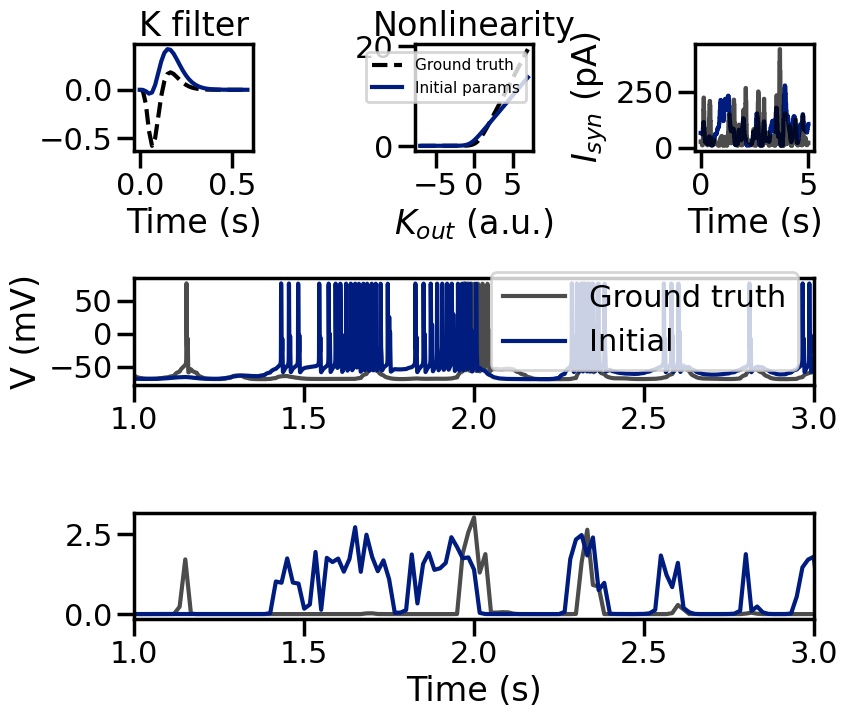

In [15]:
from jax.numpy.linalg import norm

fig = plt.figure(figsize=(6*1.5, 7*1.1), layout="constrained")
gs = fig.add_gridspec(3, 3)

axK  = fig.add_subplot(gs[0, 0])
axNL = fig.add_subplot(gs[0, 1])
axI  = fig.add_subplot(gs[0, 2])
axV  = fig.add_subplot(gs[1, :])  # spans all 3 columns
axR  = fig.add_subplot(gs[2, :])  # spans all 3 columns

axK.set_title("K filter")
axK.plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth')
axK.plot(jnp.arange(len(K0))*dt_stim,       K0/norm(K0),           c=sns.color_palette("dark")[0], label='Initial params')
axK.set_xlabel("Time (s)")

axNL.set_title("Nonlinearity")
x = jnp.linspace(-7, 7, 300)

betag  = softplus(ground_params["log_beta"]) + 1e-6
shiftg = ground_params["shift"]
gaing  = softplus(ground_params["log_gain"]) + 1e-6
r0g    = softplus(ground_params["log_r0"])

# driveg = softplus(betag * (x - shiftg))
driveg = softplus_beta(x - shiftg, betag)
Nlg = r0g + gaing * driveg


beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
gain0 = softplus(params_ln0["log_gain"]) + 1e-6
r00    = softplus(params_ln0["log_r0"])

# drive0 = softplus(beta0 * (x - shift0))
drive0 = softplus_beta(x - shift0, beta0)
Nl0 = r00 + gain0 * drive0

axNL.plot(np.array(x), np.array(Nlg), c='k', ls="--", label='Ground truth')
axNL.plot(np.array(x), np.array(Nl0), label='Initial params', c=sns.color_palette("dark")[0])

axNL.set_xlabel(r"$K_{out}$ (a.u.)")
# axNL.set_ylabel(r"$I_{syn}$ (pA)")
axNL.legend(loc='upper right', fontsize=11)

t = jnp.arange(len(I_syn0[0])) * dt_cell_s
axI.plot(t, I_syn0[0]*1000, c=sns.color_palette("dark")[0])
axI.plot(t, I_syn_ground[0]*1000, c='k', alpha=0.7)
axI.set_ylabel(r"$I_{syn}$ (pA)")
axI.set_xlabel("Time (s)")

axV.plot(t, V_ground[1], c='k', alpha=0.7, label="Ground truth")
axV.plot(t, v0[1], c=sns.color_palette("dark")[0], label="Initial")  
axR.set_xlabel("Time (s)")
axV.set_ylabel("V (mV)")
axV.legend()
axV.set_xlim(1,3)

t_spk = jnp.arange(spk_train.shape[1]) * dt_stim
# axR.plot(t_spk, spk_train[1], label="Initial")  # if you want it
axR.plot(t_spk, mu_ground[1], c='k', alpha=0.7, label="Ground truth")
axR.plot(t_spk, mu_0[1],  c=sns.color_palette("dark")[0], label="Initial")
axR.set_xlim(1,3)
fig.tight_layout()

## Train


In [16]:
import optax
from functools import partial
from jax.nn import sigmoid, softplus


def poisson_nll_from_rate(rate_hz, y_counts, dt, eps=1e-8):
    y = y_counts.astype(rate_hz.dtype)
    mu = jnp.clip(rate_hz * dt, eps, 1e6)
    return jnp.mean(mu - y * jnp.log(mu))  # + const dropped

def l2_reg(params, keys, w=1e-4):
    return w * sum(jnp.sum(params[k]**2) for k in keys)

@partial(jax.jit, static_argnames=("K","n"))
def loss_fn(params, stim_b, y_b, *, K, dt, n, max_tau):
    drive, _, _ = ln_forward(params, stim_b, K=K, dt=dt, n=n, max_tau=max_tau)
    v0, mu_0, I_syn0 =  forward_pass(drive, r_max_hz, beta, rgc_forward0, edges_hat)
    loss = poisson_nll_from_rate(mu_0, y_b, dt=dt)
    loss = loss + l2_reg(params, ["alpha_j","alpha_h","logit_tau1","logit_tau2"], w=1e-4)
    loss = loss + l2_reg(params, ["log_gain","shift","log_beta","log_r0"], w=1e-4)
    return loss

@partial(jax.jit, static_argnames=("K","n"))
def train_step(params, opt_state, stim_b, y_b, *, K, dt, n, max_tau):
    loss, grads = jax.value_and_grad(loss_fn)(params, stim_b, y_b, K=K, dt=dt, n=n, max_tau=max_tau)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


In [17]:

# Ensure stim is float; spikes can be int
stim = stim.astype(jnp.float32)
spk_train = spk_train.astype(jnp.int32)
# spk_train = y_counts.astype(jnp.int32)
key = jax.random.PRNGKey(0)

optimizer = optax.adam(3e-3)
opt_state = optimizer.init(params_ln0)


frame_rate = 60.0
dt = 1.0 / frame_rate          # Python float is fine
filt_dur = 0.6
K = int(round(filt_dur / dt))  # static integer length for the kernel

max_tau = ((K - 1) / 3.0) * dt  # Python float
n = 6
# loss_fn, train_step = make_loss_and_step(rgc_forward0, r_max_hz, beta, optimizer)

In [ ]:
N, T = stim.shape
batch_size = 16
steps = 3000
rng = key
params = params_ln0
for step in range(steps):
    rng, k = jax.random.split(rng)
    idx = jax.random.randint(k, (batch_size,), 0, N)

    stim_b = stim[idx]
    y_b    = spk_train[idx]

    params, opt_state, loss = train_step(
    params, opt_state, stim_b, y_b,
    K=K, dt=dt, n=n, max_tau=max_tau
    )

    if step % 100 == 0:
        print(f"step {step:4d} | loss {float(loss):.6f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- build learned filter + components -----
def get_filter_and_components(params, K, dt, n, max_tau):
    tau_j = sigmoid(params["logit_tau1"]) * max_tau
    tau_h = sigmoid(params["logit_tau2"]) * max_tau

    t = jnp.arange(K, dtype=jnp.float32) * dt
    x1 = t / (tau_j + 1e-12)
    x2 = t / (tau_h + 1e-12)

    Kj = params["alpha_j"] * (x1**n) * jnp.exp(-n*(x1 - 1.0))
    Kh = params["alpha_h"] * (x2**n) * jnp.exp(-n*(x2 - 1.0))
    k  = Kj - Kh

    # apply same norm as training
    k = k / (jnp.sqrt(jnp.sum(k**2) * dt) + 1e-12)
    return t, k, Kj, Kh, tau_j, tau_h

t, k_learned, Kj, Kh, tau_j, tau_h = get_filter_and_components(params, K, dt, n, max_tau)

t = np.array(t)
k_learned = np.array(k_learned)
Kj = np.array(Kj)
Kh = np.array(Kh)

print("tau_j (s):", float(tau_j), "tau_h (s):", float(tau_h))
print("alpha_j:", float(params["alpha_j"]), "alpha_h:", float(params["alpha_h"]))
print("gain:", float(softplus(params["log_gain"])), "r0:", float(softplus(params["log_r0"])))
print("beta:", float(softplus(params["log_beta"])), "shift:", float(params["shift"]))


In [ ]:
from jax.numpy.linalg import norm

fig = plt.figure(figsize=(6*1.5, 6*1.1), layout="constrained")
gs = fig.add_gridspec(2, 3)

axK  = fig.add_subplot(gs[0, 0])
axNL = fig.add_subplot(gs[0, 1])
axI  = fig.add_subplot(gs[0, 2])
axV  = fig.add_subplot(gs[1, :])  # spans all 3 columns

axK.set_title("K filter")
axK.plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth')
axK.plot(jnp.arange(len(K0))*dt_stim,       K0/norm(K0),           c=sns.color_palette("dark")[0], label='Initial params')
axK.plot(jnp.arange(len(k_learned))*dt_stim, k_learned/norm(k_learned), label='Learned params', c=sns.color_palette("bright")[0])
axK.set_xlabel("Time (s)")

axNL.set_title("Nonlinearity")
beta  = softplus(params["log_beta"]) + 1e-6
shift = params["shift"]
gain  = softplus(params["log_gain"]) + 1e-6
r0    = softplus(params["log_r0"])

# drive = softplus(beta * (x - shift))
drive = softplus_beta(x - shift, beta)
r = r0 + gain * drive

axNL.plot(np.array(x), np.array(r), label='Learned params', c=sns.color_palette("bright")[0])
axNL.plot(np.array(x), np.array(Nlg), c='k', ls="--", label='Ground truth')
axNL.plot(np.array(x), np.array(Nl0), label='Initial params', c=sns.color_palette("dark")[0])

axNL.set_xlabel(r"$K_{out}$ (a.u.)")
# axNL.set_ylabel(r"$I_{syn}$ (pA)")
axNL.legend(loc='upper right', fontsize=11)

t = jnp.arange(len(I_syn0[0])) * dt_cell_s
axI.plot(t, I_syn0[0]*1000, c=sns.color_palette("dark")[0])
axI.plot(t, I_syn_ground[0]*1000, c='k', alpha=0.7)
axI.set_ylabel(r"$I_{syn}$ (pA)")
axI.set_xlabel("Time (s)")

axV.plot(t, V_ground[1], c='k', alpha=0.7, label="Ground truth")
axV.plot(t, v0[1], c=sns.color_palette("dark")[0], label="Initial")  # if you want it
axV.set_xlabel("Time (s)")
axV.set_ylabel("V (mV)")
axV.legend()
fig.tight_layout()

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

# predictions (JAX)
rate_te, _, _ = ln_forward(params, stim_rs.astype(jnp.float32), K=K, dt=dt, n=n, max_tau=max_tau)
mu_te = rate_te * dt  # expected counts per frame

# convert to numpy for sklearn
y_true = np.asarray(spk_t_test)          # (N, T)
y_pred = np.asarray(mu_te)               # (N, T)

# 1) trial-wise R^2: compute per trial, then average
r2_trials = np.array([r2_score(y_true[i], y_pred[i]) for i in range(y_true.shape[0])])
print("test R^2 trial-wise mean±sd:", r2_trials.mean(), r2_trials.std())

# 2) PSTH R^2: compare mean across trials
psth_true = y_true.mean(axis=0)
psth_pred = y_pred.mean(axis=0)
print("test R^2 PSTH:", r2_score(psth_true, psth_pred))



## Decide objective function
- Poisson loss on expected counts/frame